# Change Analysis

[Click here](https://iom-tagapp-beta.pla.sh) to access the **IOM TAGGING (BETA) PLATFORM**

In [ ]:
from iomeval.llm_eval.changes import *

from fastcore.all import *
from iomeval.readers import load_evals
from pathlib import Path

In [ ]:
p = Path().home() / 'iomeval/data/requester_by_report_id.json'
lut = p.read_json()
evls_test = L(lut.keys())

ROOT_PATH = Path.home() / 'iomeval'
DATA_PATH = ROOT_PATH / 'data'
RESULTS_PATH = DATA_PATH/ 'results'
EVALS_PATH = ROOT_PATH / 'nbs/files/test/evaluations.json'

# Contains latest backed up data before new deployment
LATEST_TAG_PATH = Path.home() / 'tagapp/backups/20260311_115159/data'

evals = load_evals(EVALS_PATH)

In [ ]:
dfs = all_deltas(evls_test, RESULTS_PATH, LATEST_TAG_PATH)

In [ ]:
who = set(lut.values())
who


{'Andres', 'Davide', 'elma', 'ljeoma', 'pip', 'rogers'}

In [ ]:
# Automaticall generate changes report cells for all reports
rpts = [k for k,v in lut.items() if v=='Davide']
for rpt in rpts: await gen_report_cells(rpt, dfs, LATEST_TAG_PATH, RESULTS_PATH)

## What we changed?

1. First of all, we **improved the consistency of what section of an evaluation report the model reads**. A "curation" step was added to the process in which a human selects the sections of the report that are more relevant to the tagging. This step used to be automatic (it was based on the "parsing" prompt that you reviewed) but we realized that several mistakes were being made by the model (probably because of the diversity in formatting and structure of evaluation reports, which not always follow a precise template). This is a major change with likely general consequences on the tagging. *Feedback from testers on which sections of the report should be fed to the model was considered*. 

Secondly, we made changes to the tagging prompts based on your feedback. Here are the main modifications (minor ones are not listed here but are available in the files used for the review):


2. **Excerpt-based analysis clarification**: Following the point above on the new report "curation" step, we asked the model to be explicit on the fact that only specific section are accessed (executive summary, introduction, background, evaluation scope, conclusions, recommendations, lessons learnt) in order not to give a false impression that the full report was being fed to the model. Hedged language is required throughout (e.g., "the excerpts suggest …", "based on the sections reviewed …"). *This follows up on comments from several testers - some asking more precise quotation outputs (something not possible at this stage - sorry!). The reasoning now is more transparent on the fact that the model is not reading the whole report (like a human would do when tagging; remember also that in earlier experiments, feeding the whole report to the model was inflating scores throughout and making the model unusable)*.

3. **GCM 23 downgrading**: Added an important note on GCM Objective 23 clarifying its revised scoring treatment. *This follows up on feedback from different testers suggesting that relevance with respect to this objective may have been exaggerated by the model*.

4. **SRF enablers reframing**: Introduced a critical distinction between enablers as institutional capacity versus programmatic tools. *This follows up on a point raised by Pip*.

5. **Relevance score range relabelling**: Tags now use "Not Relevant", "Peripheral" (formerly "Supplementary"), "Relevant", and "Fundamental". *This follows up on suggestion from Andres*.

6. **Terminology warning on "Findings"** — Analysts must not use "finding(s)" in their own analytical language, as this term carries a specific formal meaning in IOM evaluation reports. It may only be referenced when it appears in report excerpts themselves. *This clarification stems from Andres flagging overly broad or imprecise uses of "findings" generated by the LLM*.

7. **GCM descriptions added**: The description of the GCM objective used by the model is now fully in line with the GCM UN resolution document. *This is something we realized upon auditing the script*. For instance:
```
# Objective 1
## Title: Collect and utilize accurate and disaggregated data as a basis for evidence-based policies
We commit to strengthen the global evidence base on international migration by improving and investing in the collection, analysis and dissemination of accurate , ...
To realize this commitment, we will draw from the following actions:
## Associated actions
- a. Elaborate and implement ...
- b. ...
...
```

Here are links to [new](https://github.com/franckalbinet/iomeval/tree/main/nbs/files/prompts) and [previous](https://github.com/franckalbinet/iomeval/tree/main/nbs/files/prompts/legacy) versions of the prompts.

How did these changes affect tagging?

## Score changes overview

**Based on all reports tagged so far (20)**. This is to give you a general sense of how the behavior of the model changed.

### GCM objectives

*Note: You might be unfamiliar with this type of visualization. It's called a [violin plot](https://en.wikipedia.org/wiki/Violin_plot). A violin plot combines a box plot with a smoothed estimate of the score distribution, making it easier to spot not just the median and spread, but also whether scores cluster around one or several values, something a box plot alone would miss.*

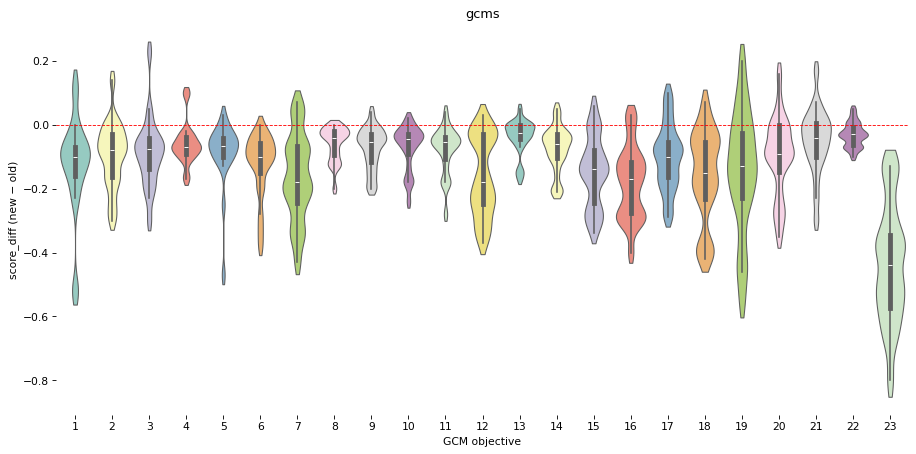

In [ ]:
plot_score_diffs(dfs, 'gcms', 'GCM objective', figsize=(12, 6), dpi=77)

### SRF Enablers

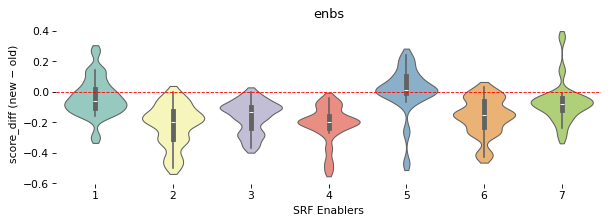

In [ ]:
plot_score_diffs(dfs, 'enbs', 'SRF Enablers', figsize=(8, 3), dpi=77)

### SRF Cross-Cutting Priorities

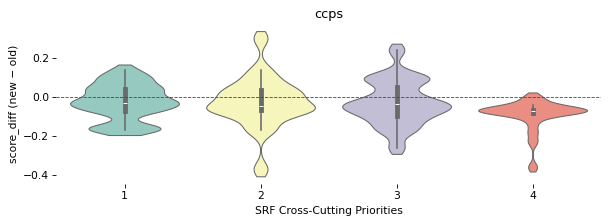

In [ ]:
plot_score_diffs(dfs, 'ccps', 'SRF Cross-Cutting Priorities', figsize=(8, 3), dpi=77)

## Rank changes overview

Among all themes where previous relevance score was `> 0.83` (**FUNDAMENTAL**), what percentage of them have undergone a change in rank (`rank_diff != 0`)

In [ ]:
dfs[dfs.score_old > 0.83].groupby('mapping_type').apply(lambda x: 100 * (x.rank_diff != 0).sum() / len(x)).round(1).sort_values()

mapping_type
ccps    16.7
gcms    34.3
outs    40.7
enbs    44.4
dtype: float64

## Our interpretation

The score changes overview charts show a general decrease of the scores. In other words, the **model became more conservative** following the various changes made to the prompts.

The reduction in scores is more pronounced and generalized for GCM objectives, possibly due to the additional details on **GCM objectives** (change 7 above) that now the model has access to. However, the reductions yet remain moderate in magnitude, suggesting the prompt revisions recalibrated the model's behaviour without disrupting it fundamentally. The dramatic average score reduction for GCM objective 23 is something intended. *It means that the changes to the prompt worked, although your feedback will say if further calibration is needed*.  

**SRF Enablers** showed the highest rank instability (44.4%). This is also expected due to their reframing in the prompt (change 4).

**CCPs** were relatively unaffected by the changes in terms of average scores and ranking, which is consistent with the fact that none of the changes specifically targeted CCP scoring logic.

**Caveat**: the current general analysis is based on 20 reports only. Patterns, especially for the objectives less covered by our sample of reports, should be interpreted with caution.

## Inputs we need from you

- Do you agree with the overall interpretation of the changes?
- Do you find the new behaviour to be improved? 
- Please check, in the reports you asked us to tag, how the new behaviour has changed the items classified as fundamental. Do you find that accuracy and sensitivity have improved? Do you find the new reasonings better? 

## Per evaluation report

**REMINDER**, our "RELEVANCE SCORE FRAMEWORK" is as follows:
- score >= 0.84: **FUNDAMENTAL**
- 0.66 <= score < 0.83: **RELEVANT**
- 0.34 <= score < 0.66: **PERIPHERAL**
- score < 0.34: **NOT RELEVANT**

### Evaluation of IOM Accountability to Affected Populations

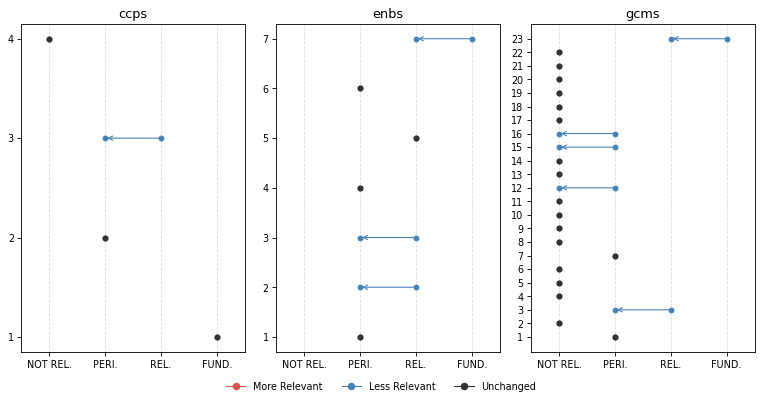

In [ ]:
plot_band_changes(dfs[dfs.evl_id == '6c3c2cf3fa479112967612b0baddab72'], figsize=(10, 5), dpi=77)

**Fundamental Themes**
| | Mapping | Theme | Score |
|---|---|---|---|
| old | ccps | 1: Integrity, Transparency and Accountability | 0.91 |
| old | enbs | 7: Internal systems | 0.85 |
| old | gcms | 23: Strengthen International Cooperation And Global Partnerships For Safe, Orderly And Regular Migration | 0.85 |
| new | ccps | 1: Integrity, Transparency and Accountability | 0.85 |

**⬇️ No Longer Fundamental**

#### ENBS 7: Internal systems

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.85 | 0.82 | 1 | 1 | 0 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on internal systems and organizational infrastructure. The evaluation's primary focus is assessing IOM's AAP Framework—an institutional system comprising policy (IN/285), guidance, resources, and coordination mechanisms. Key findings directly address: the absence of a formal monitoring and evaluation framework; gaps in standard tools and procedures; lack of integration of AAP into the project cycle; the need for institutionalization of CFM systems into 'corporate systems'; and data protection compliance challenges. The conclusions note that IOM lacks 'a formal result matrix or a theory of change for AAP' and relies on 'a collection of indicators from different institutional monitoring frameworks.' Recommendations 3, 7, and 8 specifically address developing monitoring frameworks, standardizing tools and templates, and integrating CFM systems into corporate infrastructure. For synthesis specialists examining IOM's internal systems capacities, this report provides substantial evidence on how institutional frameworks are developed, implemented, and monitored. The analysis of system fragmentation, the discussion of policy-practice gaps, and the recommendations on standardization and integration would be particularly valuable. Pay close attention to the findings on monitoring frameworks, the analysis of CFM system fragmentation in findings, and Recommendations 2, 3, 7, and 8.</details>

---

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would likely contribute meaningful evidence to a synthesis on Enabler 7 (Internal Systems), and appears to be one of the two most relevant Enablers for this report. The evaluation explicitly examines IOM's institutional systems and organizational infrastructure for AAP — including the adequacy of the AAP policy framework (IN/285), the monitoring and evaluation architecture, CFM systems and their integration into corporate systems, the project cycle, and compliance with mandatory instructions. These are assessed as organizational systems, not merely as programmatic tools. The excerpts suggest substantive analysis of: the absence of a formal strategy and M&E framework; the fragmented and non-standardized nature of CFM systems across the organization; the lack of integration of AAP into the IOM project cycle; inadequate institutional compliance monitoring; and the need for minimum standards and quality control. Recommendations 1, 3, 5, and 8 directly address institutional systems — including clarifying mandatory policy scope, developing a theory of change and M&E framework, standardizing CFM systems, and integrating AAP into corporate systems. The conclusions section appears particularly rich in institutional systems analysis, noting gaps in policy monitoring, strategic planning, and organizational infrastructure. A synthesis specialist would likely want to prioritize the conclusions and recommendations sections, particularly those addressing the AAP Framework architecture, CFM standardization, and the monitoring framework — as these appear most directly relevant to IOM's internal systems capacity. The full report may contain additional relevant evidence beyond what the excerpts reveal.</details>

#### GCMS 23: Strengthen international cooperation and global partnerships for safe, orderly and regular migration

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.85 | 0.72 | 1 | 1 | 0 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on GCM Objective 23, specifically regarding inter-agency coordination and partnerships. The evaluation explicitly examines 'collective accountability' as a core concept, assessing IOM's collaboration with United Nations agencies and partners on AAP. The conclusions state that 'collective accountability emerged as a frequent and important concept' with specific instances of effective inter-agency coordination described, including joint CFM initiatives. Recommendation 9 directly addresses continued collaboration and engagement on collective accountability, 'actively participating in coordination structures on AAP, such as IASC-promoted initiatives or initiatives developed in other inter-agency coordination spaces, both at the global and country level.' The report discusses IOM participation in IASC AAP coordination and inter-agency leadership training. Key sections for synthesis specialists include: the conclusions on collective accountability, Recommendation 9 and its associated activities, and the findings on IASC engagement. This provides direct evidence on implementation of Action 23e (partnerships that address migration policy issues) and the broader goal of international cooperation in migration governance.</details>

---

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would likely contribute meaningful evidence to a synthesis on GCM Objective 23, specifically regarding IOM's institutional role in inter-agency coordination and collective accountability mechanisms. The report appears to substantively examine IOM's engagement with IASC coordination structures, inter-agency AAP working groups, and collective accountability frameworks — themes that connect to the governance and partnership dimensions of GCM Objective 23. The concept of 'collective accountability' is described as a 'frequent and important concept' throughout the evaluation, with analysis of how IOM coordinates with other UN agencies and partners on joint CFMs and needs data. Recommendation 9 explicitly addresses continued engagement in inter-agency coordination spaces (IASC-promoted initiatives, global and country-level coordination structures), and the conclusions discuss IOM's participation in IASC as bringing benefits in resource mobilization and awareness. These elements appear to connect to actions 23a (supporting collective GCM implementation) and 23e (bilateral/multilateral partnerships on migration policy). However, a synthesis specialist should note that this report examines inter-agency coordination primarily as an operational feature of AAP delivery rather than as a governance mechanism for GCM implementation per se — the international cooperation discussed is largely programmatic coordination rather than global migration governance architecture. The sections on collective accountability in the conclusions, and Recommendation 9 with its associated activities, would appear most relevant for human reviewers to prioritize. The full report may contain additional evidence on inter-agency coordination beyond what the excerpts reveal.</details>

### Final Evaluation of the EU-IOM Joint Initiative for migrant protection and reintegration in the horn of Africa

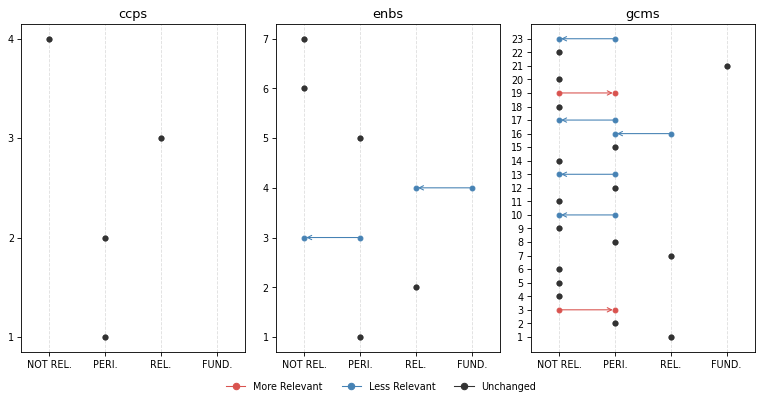

In [ ]:
plot_band_changes(dfs[dfs.evl_id == '49d2fba781b6a7c0d94577479636ee6f'], figsize=(10, 5), dpi=77)

**Fundamental Themes**
| | Mapping | Theme | Score |
|---|---|---|---|
| old | enbs | 4: Data and evidence | 0.84 |
| old | gcms | 21: Cooperate In Facilitating Safe And Dignified Return And Readmission, As Well As Sustainable Reintegration | 0.95 |
| new | gcms | 21: Cooperate In Facilitating Safe And Dignified Return And Readmission, As Well As Sustainable Reintegration | 0.97 |

**⬇️ No Longer Fundamental**

#### ENBS 4: Data and evidence

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.84 | 0.72 | 1 | 1 | 0 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on Enabler 4 (Data and Evidence). The evaluation explicitly examines the Regional Data Hub (RDH) as a core programme component, with substantial findings on data production, capacity-building for data collection, and the use of evidence in policymaking. The executive summary highlights that 'efforts of the JI-HoA regarding migration data were of particular relevance and importance to the stakeholders,' and the conclusions emphasize 'important contributions to the availability of data and research on migration trends in the region.' Specific Outcome 1 findings address 'increased use of data in policymaking, strategies, processes and plans.' The evaluation also examines the programme's own M&E work, noting it 'provided important evidence for programming' and discussing the RSS+ methodology for measuring reintegration sustainability. Recommendation 4 explicitly calls for 'support to the Regional Data Hub' and Recommendation 7 addresses continuing to 'test and adjust the tools used to measure the sustainability of reintegration' and conducting 'additional impact evaluations.' For a synthesis specialist, the Specific Outcome 1 findings, conclusions section on data contributions, and Recommendations 4 and 7 would be particularly valuable for understanding IOM's data systems, evidence generation, and organizational capacity for evidence-based decision-making.</details>

---

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would likely contribute meaningful evidence to a synthesis on Enabler 4 (Data and Evidence), and this is one of the stronger candidates for a higher score. Importantly, the JI-HoA explicitly included a 'Migration Data' pillar and established the East and Horn of Africa Regional Data Hub (RDH) as a core programme component — and the evaluation appears to assess the effectiveness of these data systems and capacity-building efforts at a level that goes beyond purely programmatic tool use. The excerpts suggest the evaluation examined whether data generated by the RDH was actually used in policymaking (Result 1.1), whether governments developed increased capacity for data collection and analysis, and whether the RDH's methodologies and indicators were harmonized across the region. Stakeholders are noted to have 'explicitly appreciated the work of the Regional Data Hub in terms of data production and capacity-building.' Recommendation 7 specifically addresses continuing to test and adjust tools for measuring reintegration sustainability (RSS+ methodology), and Recommendation 4 recommends continued support to the RDH. The conclusions section also discusses the JI-HoA's contributions to 'the availability of data and research on migration trends in the region' as a distinct impact area. While the data systems evaluated are specific to this programme rather than IOM-wide, the RDH represents an institutional data infrastructure investment that a synthesis specialist on IOM's Data and Evidence Enabler would likely find relevant. The sections on Specific Outcome 1, the Migration Data pillar activities in Table 2, and the conclusions on data contributions appear most worth prioritizing for human review.</details>

### Evaluation of Mental Health and Psychosocial Support in IOM

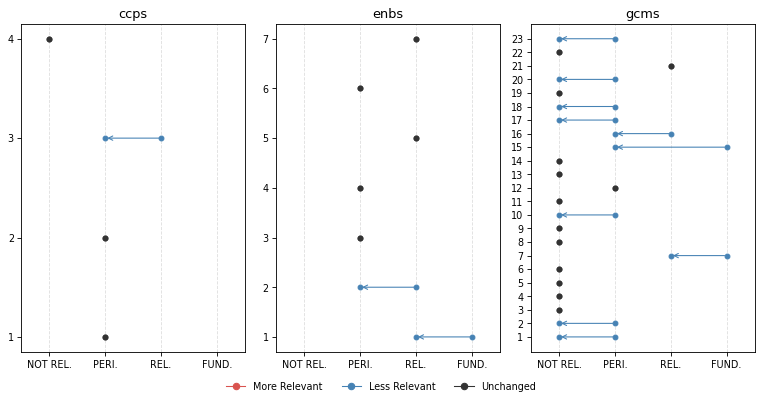

In [ ]:
plot_band_changes(dfs[dfs.evl_id == '22cac1c000836253adc445993e101560'], figsize=(10, 5), dpi=77)

**Fundamental Themes**
| | Mapping | Theme | Score |
|---|---|---|---|
| old | enbs | 1: Workforce | 0.85 |
| old | gcms | 15: Provide access to basic services for migrants | 0.88 |
| old | gcms | 7: Address and Reduce Vulnerabilities in Migration | 0.86 |

**⬇️ No Longer Fundamental**

#### ENBS 1: Workforce

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.85 | 0.78 | 1 | 1 | 0 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on Enabler 1 (Workforce). The evaluation explicitly examines IOM MHPSS workforce capacity as a central concern, with multiple findings, conclusions, and recommendations directly addressing staffing levels, technical capacity, staff wellbeing, supervision, and professional development. The Efficiency section dedicates substantial analysis to 'insufficient resourcing of technical staff capacity at global and regional levels' being 'a significant risk for quality assurance, staff wellbeing and sustainability.' A dedicated subsection on 'Staff Wellbeing Highlighted in Data Collection' addresses vicarious traumatization risks, role clarity, and staff care pathways. Recommendations 4-6 specifically address resourcing central technical staff, establishing Regional Thematic Specialists, and building organizational capacity. The report identifies gaps in supervisory roles, barriers to professional advancement, and the need for appropriate contract levels (P3 and above). For a synthesis specialist, the Efficiency section (pages 49-50), the Staff Wellbeing subsection, and Recommendations 4-6 (pages 55-56) provide direct evidence on IOM's workforce planning, staff support systems, and capacity gaps in a specialized technical area.</details>

---

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would likely contribute meaningful evidence to a synthesis on Enabler 1 (Workforce). Importantly, the evaluation appears to examine IOM's MHPSS staffing and capacity as an organizational concern — not merely as a programmatic delivery mechanism. The excerpts suggest substantive institutional-level analysis of workforce gaps, staff wellbeing, professional development, and the adequacy of technical capacity at HQ and regional levels. This distinction makes it potentially relevant to the Enabler. Specifically, the efficiency and sustainability conclusions appear to directly address IOM's organizational capacity to staff and support its MHPSS function: the evaluation notes that IOM MHPSS operates across 80+ countries with only two core staff and no Regional Technical Specialists (RTS), describes this as 'a significant risk for future sustainability' and staff wellbeing, and flags the absence of staff above P3 level as a structural concern. Recommendations 4, 5, and 6 explicitly call for resourcing central and regional technical staff capacity, establishing career pathways, and ensuring adequate supervision — all of which speak to IOM's workforce planning and people management systems as organizational capacities. The annual Summer School in Pisa and capacity-building activities also suggest some analysis of professional development. For a synthesis specialist, the efficiency and sustainability sections of the conclusions, along with Recommendations 4–6, would appear to be the most valuable starting points for deeper review. The report's focus is on MHPSS specifically rather than IOM's workforce broadly, which limits its generalizability, but the institutional framing of staffing gaps and workforce sustainability makes it more than a purely programmatic account.</details>

#### GCMS 15: Provide access to basic services for migrants

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.88 | 0.62 | 1 | 3 | -2 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on GCM Objective 15, particularly Action 15e on health needs including mental health. The evaluation explicitly examines MHPSS service provision as a core theme, noting IOM 'overseeing 148 programmes in 83 countries in 2023, which reached approximately 1.5 million beneficiaries.' The Executive Summary highlights 'community-based model uniquely suited to the experiences and needs of migrants' and 'the spectrum of IOM interventions across layers of the IASC MHPSS pyramid – from broad, community support to focused and more specialized psychological and psychiatric care.' The Conclusions section on Relevance emphasizes 'locally driven and community-grounded approaches tailored to the needs of affected populations' and 'tools and resources clearly articulating the MHPSS approach.' The report directly addresses culturally-sensitive service delivery, capacity building of service providers, and access barriers—all core themes under Action 15e. Pay close attention to: Executive Summary on service delivery scale and approach; Coherence conclusions on IASC pyramid alignment; Impact conclusions on service delivery outcomes; Recommendations 7-8 on knowledge centers and resources for service provision.</details>

---

<details><summary>Reasoning (new)</summary>The excerpts suggest meaningful peripheral-to-relevant content for GCM Objective 15, particularly action 15e on incorporating health needs of migrants in national and local health care policies, facilitating non-discriminatory access, and promoting physical and mental health of migrants. The report's core subject — MHPSS programming for migrants — directly relates to mental health service access. The evaluation discusses IOM's work across 83 countries reaching approximately 1.5 million beneficiaries, systems strengthening, and capacity building for sustained service delivery. References to health assessments, community-based approaches, and integration with national health systems are relevant to action 15e. However, the report is primarily an institutional evaluation of IOM's MHPSS approach rather than an analysis of migrant access to basic services broadly. The mental health dimension of service access is well-covered, but other basic services (education, legal aid, etc.) are not the focus. A synthesis specialist on Objective 15 — particularly its mental health dimension — might find the conclusions on effectiveness and sustainability, and the case studies, worth reviewing, though the report's institutional focus limits its direct contribution.</details>

#### GCMS 7: Address and reduce vulnerabilities in migration

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.86 | 0.72 | 2 | 2 | 0 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on GCM Objective 7. The evaluation explicitly examines MHPSS as a comprehensive approach to addressing psychological vulnerabilities of migrants, with 'community-based and inter-disciplinary approach' targeting 'particularly the most vulnerable.' The Executive Summary states IOM MHPSS reflects 'attention to all stages of migration, socio-relational and inter-cultural approaches to the needs of affected populations and beneficiaries (particularly the most vulnerable).' The Conclusions emphasize 'locally driven and community-grounded approaches tailored to the needs of affected populations and vulnerable groups.' Key findings address identification and assistance to vulnerable migrants, child-sensitive and gender-responsive approaches, unaccompanied children, and psychosocial recovery—directly relating to Actions 7b, 7c, 7e, and 7f. The case studies (Ukraine/Poland emergencies, Colombia transition/recovery) provide operational examples. Pay close attention to: Executive Summary on vulnerable populations approach; Conclusions sections on Relevance and Coherence; Effectiveness section discussing integrated approaches across thematic areas; Recommendations 4-6 on technical capacity for vulnerability responses.</details>

---

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would likely contribute meaningful evidence to a synthesis on GCM Objective 7. The evaluation appears to substantively examine MHPSS programming for migrants in vulnerable situations across the migration cycle — including emergency-affected populations, returnees, displaced persons, trafficking victims, and other vulnerable groups. The excerpts suggest that IOM's MHPSS approach explicitly targets 'the most vulnerable' across all stages of migration, with attention to gender-responsive and child-sensitive approaches (actions 7b, 7c, 7f). The report discusses psychological and counselling services, access to care, and protection referrals — directly relevant to action 7c on gender-responsive migration policies including psychological counselling. The case studies (Ukraine/Poland, West and Central Africa, Colombia) appear to illustrate MHPSS responses to vulnerability in different migration contexts. The conclusions on relevance and effectiveness sections, and Recommendation 6 on building organizational capacity, would likely be most valuable for a synthesis specialist to review. The report's focus is primarily institutional/organizational rather than policy-level vulnerability reduction, which limits the score somewhat, but the programmatic content on serving vulnerable migrants appears substantive.</details>

### Impact evaluation of the UN Secretary General’s Peacebuilding Fund-supported  East Darfur Assalaya-Sheiria-Yassin  Triangle of Peace and Coexistence project

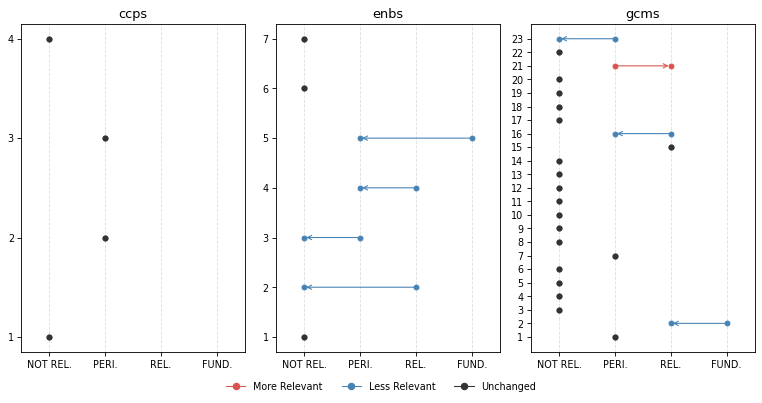

In [ ]:
plot_band_changes(dfs[dfs.evl_id == 'e8d9427f4a9094f68e17307faa567d8b'], figsize=(10, 5), dpi=77)

**Fundamental Themes**
| | Mapping | Theme | Score |
|---|---|---|---|
| old | enbs | 5: Learning and Innovation | 0.85 |
| old | gcms | 2: Minimize the adverse drivers and structural factors that compel people to leave their country of origin | 0.88 |

**⬇️ No Longer Fundamental**

#### ENBS 5: Learning and Innovation

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.85 | 0.38 | 1 | 2 | -1 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on Learning and Innovation. The evaluation explicitly fills an evidence gap, noting that 'virtually no impact evaluation evidence exists' for bundled peacebuilding interventions that have 'become increasingly common in recent years.' The report represents organizational learning about what works in fragile contexts—providing the first rigorous evidence on bundled programming effectiveness. The conclusions section explicitly states this is 'a first piece of evidence supporting the effectiveness of the bundled approach' and calls for 'future research' to unpack treatment components. The report demonstrates IOM's capacity to generate actionable learning through rigorous evaluation methods in challenging environments. For a synthesis specialist, Section 7 (Discussion) and Section 8 (Conclusion) are particularly valuable, as they situate findings within broader knowledge gaps and identify implications for programming. The methodology section demonstrates innovation in applying quasi-experimental designs in conflict settings. The finding that PBF-supported interventions reduced land conflicts and improved service outcomes represents concrete evidence that can inform future programming decisions across fragile contexts.</details>

---

<details><summary>Reasoning (new)</summary>The excerpts reviewed contain some content that could peripherally inform a synthesis on Enabler 5, primarily through the evaluation's explicit framing around filling an evidence gap on bundled peacebuilding programming. The report notes that 'virtually no impact evaluation evidence exists' on the effectiveness of bundled multi-agency interventions of this type, and positions itself as generating new knowledge to inform future programming design. The discussion section and conclusion explicitly call for future research to unpack which components of the treatment bundle drive results, suggesting a learning orientation. Additionally, the quasi-experimental research design using IOM's DTM data represents a methodological innovation in fragile-context evaluation. However, these elements reflect the evaluation's contribution to the broader evidence base rather than an assessment of IOM's organizational learning and innovation systems or knowledge management practices as institutional capacities. There is no analysis of how IOM captures, shares, or scales learning across its operations. The content here is programmatic rather than institutional. A synthesis specialist focused on IOM's Learning and Innovation Enabler would find only marginal value, primarily in the report's framing of evidence gaps and its methodological approach — worth considering only if evidence from other sources is limited.</details>

#### GCMS 2: Minimize the adverse drivers and structural factors that compel people to leave their country of origin

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.88 | 0.82 | 1 | 1 | 0 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on GCM Objective 2. The evaluation explicitly examines a peacebuilding intervention designed to address root causes of displacement and conflict in Darfur—a primary driver of migration. The project's theory of change directly targets adverse drivers: land conflicts, weak governance, lack of basic services, and inter-communal disputes. Key findings show reduced land conflicts (one fewer conflict per 14 households), increased school enrollment (11 percentage points higher), and improved service satisfaction. The report provides direct evidence on addressing structural factors (Actions 2b, 2d, 2f) including rule of law, governance, education, and creating peaceful societies. Sections to review: Executive Summary for outcome statistics; Section 6 for detailed findings on conflict reduction and service provision; Section 7 Discussion for analysis of intervention scope and limitations; Section 8 Conclusion for programmatic implications. The bundled intervention approach (combining dispute resolution, services, governance support) offers valuable evidence on integrated programming to address displacement drivers.</details>

---

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would likely contribute meaningful evidence to a synthesis on GCM Objective 2. The entire evaluation appears centered on a peacebuilding intervention explicitly designed to address structural drivers of displacement and conflict in Darfur — including land disputes, weak governance, lack of basic services, and inter-communal tensions. These align closely with Action 2b (investing in programmes addressing poverty, food security, education, rule of law, good governance, and peaceful societies) and Action 2f (strengthening collaboration between humanitarian and development actors). The project's theory of change, described in Section 2, directly targets conditions that compel people to leave — land conflicts, lack of services, insecurity — and the evaluation measures whether these were reduced. The qualitative results in Section 6.7 explicitly show residents attributing stability and population retention to improved services and conflict resolution. The discussion in Section 7 also engages with the limits of local peacebuilding when national-level drivers remain unaddressed. For a synthesis specialist, Sections 2 (theory of change), 6.1 (conflict results), 6.7 (qualitative results on services and stability), and 7 (discussion of local vs. national drivers) would appear particularly valuable as starting points. It is possible the full report contains additional relevant evidence beyond what the excerpts reveal.</details>

### MALDIVES: STRENGTHENING GOVERNMENT CAPACITY IN MIGRATION HEALTH POLICY DEVELOPMENT

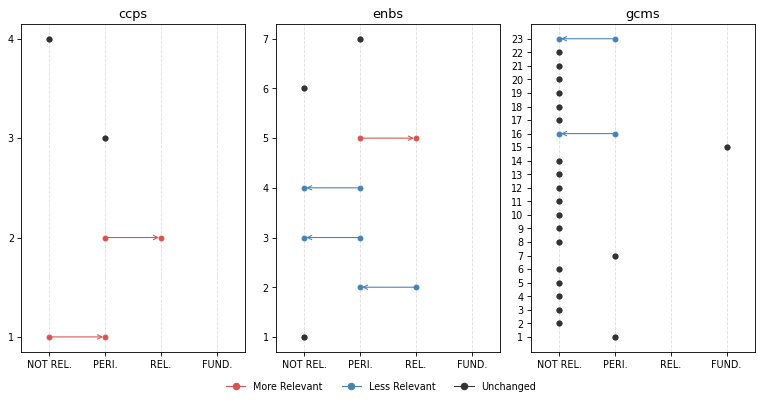

In [ ]:
plot_band_changes(dfs[dfs.evl_id == 'a493c447cff3e03ca94024335d5c5c7a'], figsize=(10, 5), dpi=77)

**Fundamental Themes**
| | Mapping | Theme | Score |
|---|---|---|---|
| old | gcms | 15: Provide access to basic services for migrants | 0.88 |
| new | gcms | 15: Provide access to basic services for migrants | 0.88 |

### EX-POST EVALUATION OF THE PROJECT: SRI LANKA: UNDERSTANDING MIGRATION, ENVIRONMENTAL DEGRADATION AND CLIMATE CHANGE

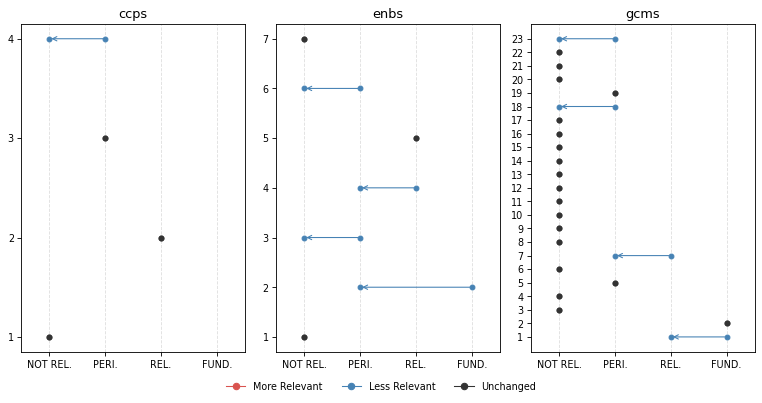

In [ ]:
plot_band_changes(dfs[dfs.evl_id == '06fd0949dc874f388686461c19d2669c'], figsize=(10, 5), dpi=77)

**Fundamental Themes**
| | Mapping | Theme | Score |
|---|---|---|---|
| old | enbs | 2: Partnership | 0.85 |
| old | gcms | 1: Collect and utilize accurate and disaggregated data as a basis for evidence-based policies | 0.85 |
| old | gcms | 2: Minimize the adverse drivers and structural factors that compel people to leave their country of origin | 0.92 |
| new | gcms | 2: Minimize the adverse drivers and structural factors that compel people to leave their country of origin | 0.88 |

**⬇️ No Longer Fundamental**

#### ENBS 2: Partnership

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.85 | 0.55 | 1 | 2 | -1 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on Partnership. Partnership development and management appears as a core theme throughout the evaluation, with strategic partnerships explicitly cited as 'critical role in the effective implementation of the project.' The evaluation examines IOM's partnerships with local NGOs (Janathakshan, SAFE Foundation, IPS), government entities (Ministry of Environment, Divisional Secretariat offices), and UN agencies (FAO, WFP). The Coherence section (Score 4.5) directly addresses how 'robust communication and collaboration with key partners' ensured well-integrated interventions. Recommendations explicitly call for 'enhancing partnerships within the UN system' and maintaining relationships with UNDP. For synthesis specialists, the findings on partnership models, the coherence assessment, and recommendations on strengthening UN system partnerships would be particularly valuable. The report provides direct evidence on how IOM leverages local partners for implementation and coordinates within the UN system on migration-climate issues.</details>

---

<details><summary>Reasoning (new)</summary>The excerpts reviewed contain recurring references to partnerships — with local NGOs (Janathakshan, SAFE Foundation), government ministries, UN agencies (FAO, WFP, UNDP), and academic institutions — and these partnerships appear to have been assessed as part of the project evaluation. However, applying the critical institutional vs. programmatic distinction, the partnerships described appear to function primarily as delivery mechanisms for the MECC Project rather than as the object of an evaluation of IOM's institutional partnership capacity. The evaluation assesses how well partnerships contributed to project outcomes (e.g., 'strategic partnerships with local NGOs played a critical role'), but does not appear to examine IOM's broader partnership frameworks, equity of partnership arrangements, or organization-wide partnership systems. The coherence section and some recommendations touch on UN system collaboration, which edges toward institutional-level analysis. A synthesis specialist focused on IOM's Partnership Enabler might find marginal value in the coherence section and the recommendations on strengthening UN system partnerships, but should note that the partnership content is largely programmatic in framing. This is a borderline case — scored in the PERIPHERAL range given the programmatic rather than institutional orientation of the partnership analysis visible in the excerpts.</details>

#### GCMS 1: Collect and utilize accurate and disaggregated data as a basis for evidence-based policies

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.85 | 0.72 | 2 | 2 | 0 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on GCM Objective 1. The MECC Project's core focus was generating evidence on the migration-climate change nexus to inform policy. The project produced an 'In-depth research report on human mobility and climate change' (Output 1.1) and built upon a 2018 joint rapid assessment covering 10 districts. Key findings indicate the research filled 'critical information gaps' and enabled 'evidence-based migration policies.' The executive summary notes successful development of data on migration patterns and climate change impacts. For synthesis specialists, pay close attention to: (1) the research methodology section describing data collection across climatic zones; (2) findings on how the research informed the National Climate Change Policy 2023; (3) the Participatory Vulnerability and Capability Analysis Framework (PVCA) used for community-level assessment. Actions 1a (improving migration data), 1j (country-specific migration profiles), and 1k (research on migration-sustainability interrelationship) are directly addressed.</details>

---

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would likely contribute meaningful evidence to a synthesis on GCM Objective 1. The MECC Project appears to have been substantially grounded in research and data generation — the excerpts describe a joint rapid assessment (IOM/FAO/WFP) that identified evidence gaps on climate-migration linkages, and Output 1.1 explicitly calls for an 'in-depth research report on human mobility and climate change.' The project appears to have generated primary research data that is now being used by university researchers, suggesting data dissemination and use. The evaluation also employed disaggregated data approaches (gender-disaggregated community assessments). These elements relate to GCM Actions 1d (data on effects of migration), 1k (research on migration-sustainable development interrelationship), and potentially 1j (country-specific migration profiles). However, data collection and analysis appear to be instrumental to the project's policy objectives rather than the primary focus of the evaluation itself. Synthesis specialists would likely want to review the sections on Output 1.1 and the research methodology, as well as the discussion of how research findings fed into policy — framed as pointers for further review rather than definitive characterizations.</details>